# Movie Genre Classification


## 1. Import Libraries

In [18]:
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 180)

## 2. Locate Dataset Files


In [19]:
NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = (NOTEBOOK_DIR / ".." / "datasets").resolve()

print("Current notebook directory:", NOTEBOOK_DIR)
print("Expected dataset directory:", DATASET_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}\n"
        "Create the folder and place train_data.txt, test_data.txt, and test_data_solution.txt inside it."
    )

all_files = sorted([path for path in DATASET_DIR.rglob("*") if path.is_file()])
print("Files found:")
for path in all_files:
    print("-", path.relative_to(DATASET_DIR))

Current notebook directory: c:\Users\bhard\CODSOFT\Movie Genre Classification\code file
Expected dataset directory: C:\Users\bhard\CODSOFT\Movie Genre Classification\datasets
Files found:
- test_data.txt
- test_data_solution.txt
- train_data.txt


## 3. Load Text Dataset

In [20]:
def find_file(filename):
    matches = list(DATASET_DIR.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} inside {DATASET_DIR}")
    return matches[0]


train_path = find_file("train_data.txt")
test_path = find_file("test_data.txt")
solution_path = find_file("test_data_solution.txt")

print("Train file:", train_path)
print("Test file:", test_path)
print("Solution file:", solution_path)

Train file: C:\Users\bhard\CODSOFT\Movie Genre Classification\datasets\train_data.txt
Test file: C:\Users\bhard\CODSOFT\Movie Genre Classification\datasets\test_data.txt
Solution file: C:\Users\bhard\CODSOFT\Movie Genre Classification\datasets\test_data_solution.txt


In [21]:
def load_train_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            parts = [part.strip() for part in line.split(":::")]
            if len(parts) >= 4:
                movie_id, title, genre = parts[0], parts[1], parts[2]
                plot = " ".join(parts[3:]).strip()
                rows.append({"id": movie_id, "title": title, "genre": genre, "plot": plot})
    return pd.DataFrame(rows)


def load_test_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            parts = [part.strip() for part in line.split(":::")]
            if len(parts) >= 3:
                movie_id, title = parts[0], parts[1]
                plot = " ".join(parts[2:]).strip()
                rows.append({"id": movie_id, "title": title, "plot": plot})
    return pd.DataFrame(rows)


def load_solution_file(path):
    return load_train_file(path)


train_df = load_train_file(train_path)
test_df = load_test_file(test_path)
solution_df = load_solution_file(solution_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Solution shape:", solution_df.shape)
display(train_df.head())

Train shape: (54214, 4)
Test shape: (54200, 3)
Solution shape: (54200, 4)


,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,"Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he re..."
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close ...
2,3,"Young, Wild and Wonderful (1980)",adult,"As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect that the students are there for more than just another..."
3,4,The Secret Sin (1915),drama,"To help their unemployed father make ends meet, Edith and her twin sister Grace work as seamstresses . An invalid, Grace falls prey to the temptations of Chinatown opium and be..."
4,5,The Unrecovered (2007),drama,"The film's title refers not only to the un-recovered bodies at ground zero, but also to the state of the nation at large. Set in the hallucinatory period of time between Septem..."


## 4. Basic Data Audit

In [22]:
print("Missing values in train data:")
display(train_df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows in train data:", train_df.duplicated().sum())
print("Number of genres:", train_df["genre"].nunique())

genre_counts = train_df["genre"].value_counts()
display(genre_counts.to_frame("count"))

Missing values in train data:


,missing_count
id,0
title,0
genre,0
plot,0



Duplicate rows in train data: 0
Number of genres: 27


,count
genre,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


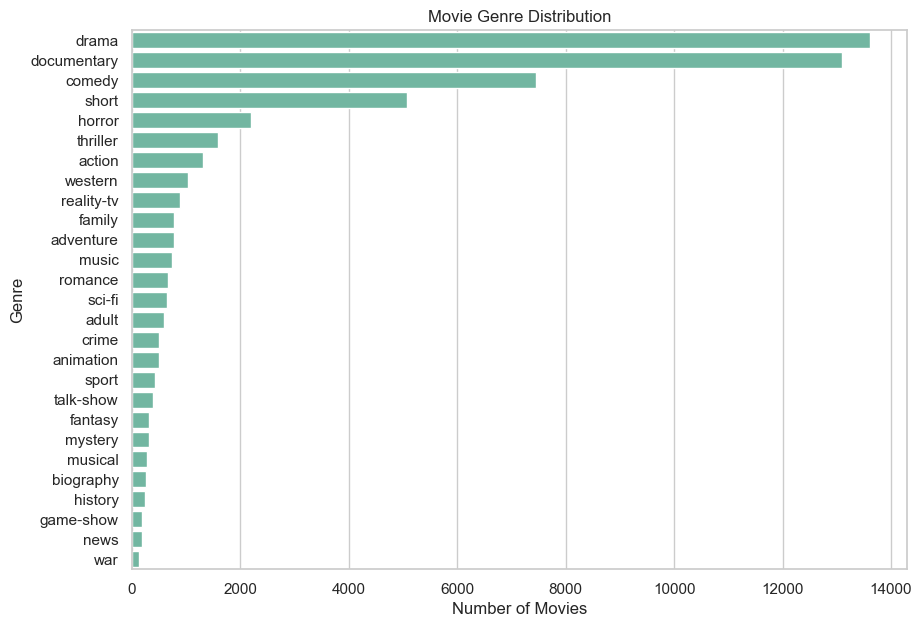

In [23]:
plt.figure(figsize=(10, 7))
sns.countplot(data=train_df, y="genre", order=train_df["genre"].value_counts().index)
plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

,plot_length_words
count,54214.000000
mean,101.907386
std,76.579192
min,6.000000
25%,55.000000
50%,79.000000
75%,121.000000
max,1829.000000


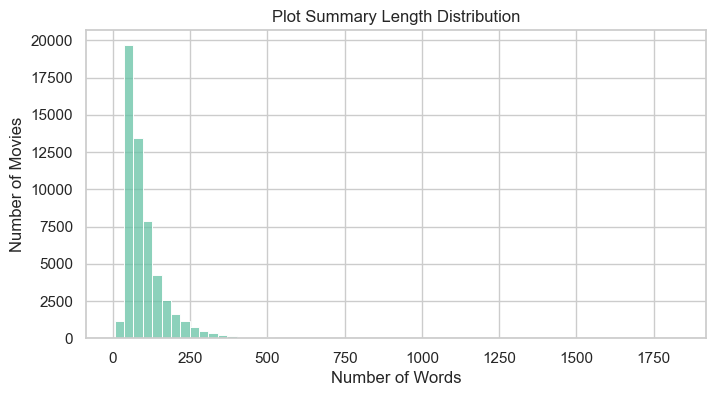

In [24]:
train_df["plot_length_words"] = train_df["plot"].str.split().str.len()

display(train_df["plot_length_words"].describe().to_frame("plot_length_words"))

plt.figure(figsize=(8, 4))
sns.histplot(train_df["plot_length_words"], bins=60)
plt.title("Plot Summary Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Movies")
plt.show()

## 5. Clean Text

In [25]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_df["clean_plot"] = train_df["plot"].apply(clean_text)
test_df["clean_plot"] = test_df["plot"].apply(clean_text)
solution_df["clean_plot"] = solution_df["plot"].apply(clean_text)

display(train_df[["title", "genre", "plot", "clean_plot"]].head())

,title,genre,plot,clean_plot
0,Oscar et la dame rose (2009),drama,"Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he re...",listening in to a conversation between his doctor and parents 10 year old oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuse...
1,Cupid (1997),thriller,A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close ...,a brother and sister with a past incestuous relationship have a current murderous relationship he murders the women who reject him and she murders the women who get too close t...
2,"Young, Wild and Wonderful (1980)",adult,"As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect that the students are there for more than just another...",as the bus empties the students for their field trip to the museum of natural history little does the tour guide suspect that the students are there for more than just another ...
3,The Secret Sin (1915),drama,"To help their unemployed father make ends meet, Edith and her twin sister Grace work as seamstresses . An invalid, Grace falls prey to the temptations of Chinatown opium and be...",to help their unemployed father make ends meet edith and her twin sister grace work as seamstresses an invalid grace falls prey to the temptations of chinatown opium and become...
4,The Unrecovered (2007),drama,"The film's title refers not only to the un-recovered bodies at ground zero, but also to the state of the nation at large. Set in the hallucinatory period of time between Septem...",the film s title refers not only to the un recovered bodies at ground zero but also to the state of the nation at large set in the hallucinatory period of time between septembe...


## 6. Train/Validation Split

In [26]:
X = train_df["clean_plot"]
y = train_df["genre"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

Training rows: 43371
Validation rows: 10843


## 7. Build and Compare Models


In [27]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent", random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42,
    ),
}

trained_models = {}
evaluation_rows = []

for name, model in models.items():
    print(f"Training {name}...")
    
    pipeline = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.90,
                    max_features=120_000,
                    sublinear_tf=True,
                ),
            ),
            ("model", model),
        ]
    )
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    trained_models[name] = pipeline
    evaluation_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_valid, y_pred),
            "macro_f1": f1_score(y_valid, y_pred, average="macro"),
            "weighted_f1": f1_score(y_valid, y_pred, average="weighted"),
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("weighted_f1", ascending=False)
display(evaluation_df)

Training Dummy Baseline...
Training Multinomial Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


,model,accuracy,macro_f1,weighted_f1
3,Linear SVM,0.578991,0.388714,0.573988
2,Logistic Regression,0.516831,0.379048,0.532916
1,Multinomial Naive Bayes,0.451904,0.050748,0.315322
0,Dummy Baseline,0.251130,0.014868,0.100815


## 8. Validation Performance of Best Model

In [28]:
best_model_name = evaluation_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model based on validation weighted F1:", best_model_name)

y_valid_pred = best_model.predict(X_valid)
print(classification_report(y_valid, y_valid_pred, zero_division=0))

Best model based on validation weighted F1: Linear SVM
              precision    recall  f1-score   support

      action       0.36      0.48      0.41       263
       adult       0.51      0.66      0.57       118
   adventure       0.31      0.29      0.30       155
   animation       0.20      0.22      0.21       100
   biography       0.00      0.00      0.00        53
      comedy       0.59      0.58      0.58      1490
       crime       0.18      0.14      0.16       101
 documentary       0.74      0.79      0.77      2619
       drama       0.65      0.58      0.62      2723
      family       0.23      0.23      0.23       157
     fantasy       0.21      0.15      0.18        65
   game-show       0.66      0.64      0.65        39
     history       0.19      0.12      0.15        49
      horror       0.57      0.75      0.65       441
       music       0.55      0.75      0.63       146
     musical       0.28      0.16      0.21        55
     mystery       0.10   

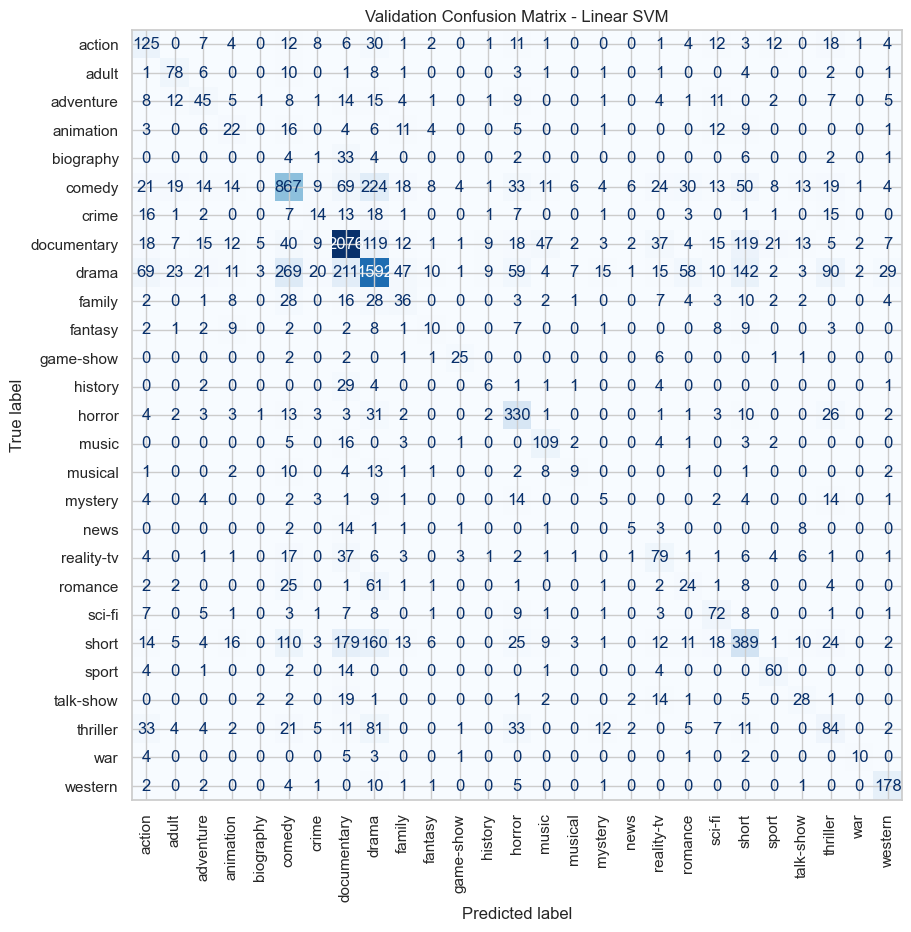

In [29]:
labels = sorted(y.unique())
cm = confusion_matrix(y_valid, y_valid_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format="d", colorbar=False)
plt.title(f"Validation Confusion Matrix - {best_model_name}")
plt.show()

## 9. Evaluate on Provided Test Solution

In [30]:
# Retrain the best model type on the full training data before final test evaluation.
best_model_full = trained_models[best_model_name]
best_model_full.fit(train_df["clean_plot"], train_df["genre"])

test_predictions = best_model_full.predict(test_df["clean_plot"])

test_results_df = test_df[["id", "title", "plot"]].copy()
test_results_df["predicted_genre"] = test_predictions

# The solution file includes the true genre for the provided test set.
test_eval_df = test_results_df.merge(
    solution_df[["id", "genre"]].rename(columns={"genre": "true_genre"}),
    on="id",
    how="inner",
)

print("Rows evaluated:", len(test_eval_df))
print("Test accuracy:", accuracy_score(test_eval_df["true_genre"], test_eval_df["predicted_genre"]))
print("Test macro F1:", f1_score(test_eval_df["true_genre"], test_eval_df["predicted_genre"], average="macro"))
print("Test weighted F1:", f1_score(test_eval_df["true_genre"], test_eval_df["predicted_genre"], average="weighted"))

print("\nClassification report on provided test solution:")
print(classification_report(test_eval_df["true_genre"], test_eval_df["predicted_genre"], zero_division=0))
display(test_eval_df.head(10))

Rows evaluated: 54200
Test accuracy: 0.5828228782287823
Test macro F1: 0.39269751760609267
Test weighted F1: 0.5796016529381482

Classification report on provided test solution:
              precision    recall  f1-score   support

      action       0.36      0.49      0.41      1314
       adult       0.48      0.61      0.54       590
   adventure       0.32      0.30      0.31       775
   animation       0.28      0.24      0.26       498
   biography       0.05      0.02      0.03       264
      comedy       0.60      0.58      0.59      7446
       crime       0.22      0.21      0.22       505
 documentary       0.75      0.79      0.77     13096
       drama       0.66      0.60      0.63     13612
      family       0.26      0.26      0.26       783
     fantasy       0.16      0.14      0.15       322
   game-show       0.69      0.73      0.71       193
     history       0.10      0.05      0.07       243
      horror       0.54      0.72      0.62      2204
       musi

,id,title,plot,predicted_genre,true_genre
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apartment, his job, but especially his girlfriend, Vespa. One day while showering, Vespa runs out of shampoo. L.R. runs across the stre...",short,thriller
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty child of three belonging to a wealthy middle-class family. Since Cristina's birth, he feels he has lost the privileged position of ""p...",drama,comedy
2,3,Off the Beaten Track (2010),"One year in the life of Albin and his family of shepherds in the North of Transylvania. In direct cinema style, this documentary follows their day to day routines, and their st...",documentary,documentary
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his brother for about 10 years and has a serious cancer. Diego is a talented film director with difficulty to deal with his sickness,...",drama,drama
4,5,Er nu zhai (1955),"Before he was known internationally as a martial arts superstar, Bruce Lee had appeared in a handful of Hong Kong films as a child star in the 1940s/50s. One of these early fil...",drama,drama
5,6,Riddle Room (2016),"Emily Burns is being held captive in a room with no idea as to why or how she got there. Determined to escape and return to her daughter and husband, Emily discovers clues with...",adult,horror
6,7,L'amica (1969),"The beautiful but neglected wife of a brilliant architect from Milan, betrayed by her husband and mocked by her friend who manages the amorous adventures that she dreams of hav...",drama,drama
7,8,Ina Mina Dika (1989),Vasu Inamdar (Ina) suffers from a disorder where the pictures which he sees comes in his dreams and turn into reality. He discusses this with his wife Shalu and his best friend...,comedy,comedy
8,9,Equinox Special: Britain's Tornados (2005),"An insight into the tornados that hit Kensal Rise in 2006 and Birmingham in 2005. Surprisingly for a country with a reputation for moderate weather, Britain has more tornadoes ...",documentary,documentary
9,10,Press (2011),Press is a story of young people overwhelmed by social discord and their surroundings. The film concisely depicts multiple factors underlying this situation. These are things t...,documentary,drama


## 10. Inspect Sample Predictions

In [31]:
sample_predictions = test_eval_df.sample(10, random_state=42)[
    ["title", "true_genre", "predicted_genre", "plot"]
]
display(sample_predictions)

,title,true_genre,predicted_genre,plot
7722,Aranyer Din Ratri (1970),drama,drama,"A group of four middle class workers in India take the week off to have a holiday. When they get to the forest, they meet up with another group and spend their time flirting wi..."
3189,Giorni e nuvole (2007),drama,drama,"Manager Michele lost his job but didn't tell his wife Eve, who was completing her art history PhD. Michele ponders whether to accept quickly a less lucrative job or hope for a ..."
926,Band of Rebels: White Horses of Camargue (2016),short,documentary,"Presenting sweeping panoramas of the horses galloping through the Camargue marshlands of Southern France, this video explores the relationship of the gardian caretakers and the..."
28907,"""The Closet"" (2016)",drama,drama,The underlining premise is the secrets that people keep that hurt the relationships they have. The primary focus is on the men/women who have sexually abused someone (mainly ch...
43417,When Piers Met Andrew Lloyd Webber (2011),documentary,documentary,With unprecedented access Piers Morgan gains a rarely seen side of Lord Lloyd Webber at rest in his private Mediterranean hideaway and at work in the heart of his showbiz empir...
11597,Ishq Wala Love (2014),romance,romance,Ajinkiya is a lawyer and loves music he is in search for a girl for his music video he meets Ovi a banker and a career oriented female and love blossoms between them with their...
11212,Usagi doroppu (2011),comedy,drama,"Movie adaptation of the manga ""Usagi Doroppu"". Daikichi (Matsuyama) a 27 year-old working man returns home to attend his grandfather's funeral. There, he meets his grandfather ..."
45552,40-ci qapi (2009),drama,drama,"Fourteen-year-old Rustam lives with his mother in a village; his father was killed by the Russian mafia. After his father's death, Rustam tries to provide for himself and his m..."
50557,"""La Supercafetera"" (2010)",sci-fi,sci-fi,"Two geeks and a blonde get a special coffee machine which gives superpowers for a limited time. They start using their powers for their own good, when a trip to the future reve..."
33946,Adam a Eva (1922),comedy,sci-fi,"Twins Adam and Eva are so alike, it is impossible to tell them apart, which enables the malicious Eva to get away with all sorts of naughty tricks and leave the blame to fall o..."


## 11. Predict Genre for a New Plot Summary

In [32]:
def predict_movie_genre(plot_summary):
    cleaned = clean_text(plot_summary)
    prediction = best_model_full.predict([cleaned])[0]
    return prediction


example_plot = "A detective investigates a mysterious murder in a quiet town and uncovers a dangerous conspiracy."
print("Example plot:", example_plot)
print("Predicted genre:", predict_movie_genre(example_plot))

Example plot: A detective investigates a mysterious murder in a quiet town and uncovers a dangerous conspiracy.
Predicted genre: mystery


## 12. Save Model and Predictions

In [33]:
MODEL_DIR = (NOTEBOOK_DIR / "models").resolve()
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "movie_genre_classifier.joblib"
joblib.dump(best_model_full, model_path)

predictions_path = NOTEBOOK_DIR / "movie_genre_test_predictions.csv"
test_results_df.to_csv(predictions_path, index=False)

print("Saved model to:", model_path)
print("Saved predictions to:", predictions_path)

Saved model to: C:\Users\bhard\CODSOFT\Movie Genre Classification\code file\models\movie_genre_classifier.joblib
Saved predictions to: c:\Users\bhard\CODSOFT\Movie Genre Classification\code file\movie_genre_test_predictions.csv


## Conclusion

This notebook completed a full movie genre classification workflow:

- Loaded the official Codsoft/Kaggle IMDb genre classification dataset.
- Parsed the text files into structured DataFrames.
- Explored genre balance and plot summary lengths.
- Cleaned plot text for NLP modelling.
- Trained TF-IDF based Naive Bayes, Logistic Regression, and Linear SVM classifiers.
- Evaluated performance using accuracy, macro F1, weighted F1, classification reports, and confusion matrix.
- Tested the best model on the provided test solution file.
- Saved the trained classifier and prediction CSV.
